### Training script BERT 

Why BERT? 
LLMs are overkill for this problem. 
BERT is more efficient. 
Based on huggingface tutorial. 

### Import necessary packages & load data 

In [1]:
from datasets import load_from_disk
import datasets 
from transformers import AutoTokenizer 
import sys
sys.path.append("/mimer/NOBACKUP/groups/naiss2024-22-903/LLMedu")
from data.CyberMetric import CyberMetric_evaluator
from openai import OpenAI 
import re
import evaluate
import numpy as np
import torch 
#!pip install nlpaug
from transformers import Trainer 
from torch import nn 
num_classes = 9

KAs = {"0": "miscellaneous (this includes Computer Science, Business and Law, Communication and Networking, Information Technology, Cyberspace Practice, Pedagogy, and Intelligence)",
           "1": "data security", 
           "2": "software security",
           "3": "component security", 
           "4": "connection security", 
           "5": "system security", 
           "6": "human security", 
           "7": "organizational security",
           "8": "societal security"}

/mimer/NOBACKUP/groups/naiss2024-22-903/anaconda3/envs/RL/lib/python3.8/site-packages/transformers/utils/hub.py:128: FutureWarning: Using `TRANSFORMERS_CACHE` is deprecated and will be removed in v5 of Transformers. Use `HF_HOME` instead.
  warnings.warn(


In [14]:
from sklearn.utils.class_weight import compute_class_weight 
def clean_text(text): 
    special_chars = r'[\"\[\]\',]'
    cleaned_text = re.sub(special_chars, '', text)
    # replace - or _ with space 
    special_chars = r'[\_\-]'
    cleaned_text2 = re.sub(special_chars,' ', cleaned_text)
    return cleaned_text2 

clf_metrics = evaluate.combine(["accuracy", "f1", "precision", "recall"])

def sigmoid(x):
   return 1/(1 + np.exp(-x))

def compute_metrics(eval_pred):
   predictions, labels = eval_pred
   predictions = sigmoid(predictions)
   predictions = (predictions > 0.5).astype(int).reshape(-1)
   return clf_metrics.compute(predictions=predictions, references=labels.astype(int).reshape(-1))

def preprocess_function(example, tokenizer):
    text = f"{example['Statement Description']}"  # our text to be labeled is the description of the KD
    text = text[13:]                              # remove "Knowledge of" since it's the same for every KD
    text = clean_text(text)                       # remove special characters
    one_hot = list(example.values())[0:9]         # read one-hot encoding 
    example = tokenizer(text)                     # tokenize text 
    example['labels'] = torch.tensor(one_hot).float()
    return example 

# custom trainer with class weights, from: https://discuss.huggingface.co/t/how-can-i-use-class-weights-when-training/1067/6
class CustomTrainer(Trainer):
    def compute_loss(self, model, inputs, num_items_in_batch=None, return_outputs=False):
        labels = inputs.get("labels")
        # forward pass
        outputs = model(**inputs)
        logits = outputs.get('logits')
        # compute custom loss [0.28267562272600055, 0.23929471032745592, 0.055695493982647636, 0.022949902043101034, 0.052616848586621884, 0.1575706689056815, 0.04114189756507137, 0.12930310663308145, 0.018751749230338653]
        # [0.3248811410459588, 0.08399366085578447, 0.04120443740095087, 0.025356576862123614, 0.12678288431061807, 0.08240887480190175, 0.00792393026941363, 0.27892234548335976, 0.028526148969889066]
        loss_fct = nn.CrossEntropyLoss(weight=torch.tensor(self.normalized_weights).cuda())
        loss = loss_fct(logits.view(-1, self.model.config.num_labels), labels)      
        return (loss, outputs) if return_outputs else loss

    def compute_weights(self, dataset): 
        non_oh = np.concatenate([list(np.where(np.array(row)==1.)[0]) for row in dataset['labels']], axis=0)
        self.normalized_weights = compute_class_weight("balanced",classes=np.unique(non_oh), y=non_oh)
        #counts, bins = np.histogram(non_oh, bins=[0,1,2,3,4,5,6,7,8,9])
        #counts = np.bincount(non_oh)
        
        # compute class weights = n_samples / (n_classes * n_samplesj)
        #weights = [1/x for x in counts]
        #self.normalized_weights = [ 9*x / sum(weights) for x in weights]

In [15]:
from datasets import load_from_disk
import datasets 
from transformers import AutoTokenizer 
ds = load_from_disk("data/train.hf")
# convert to csv (necessary for k-fold cross validation
ds.to_csv("data/train_data.csv")

Creating CSV from Arrow format:   0%|          | 0/1 [00:00<?, ?ba/s]

63775

In [16]:
from transformers import AutoTokenizer
from transformers import AutoModelForSequenceClassification, TrainingArguments, Trainer
from transformers import DataCollatorWithPadding
from sklearn.model_selection import StratifiedKFold, KFold
from transformers import set_seed 
import copy
set_seed(42)

tokenizer = AutoTokenizer.from_pretrained('distilbert-base-uncased')  
# to create a batch of examples. This dynamically pads the text to the lenght of the longest element in the batch. 
def preprocess(example):
        # preprocess and tokenize data 
        text = f"{example['Statement Description']}"       # our text to be labeled is the description of the KD
        text = text[13:]                                   # remove "Knowledge of" since it's the same for every KD
        text = clean_text(text)                            # remove special characters
        one_hot = list(example.values())[0:9]              # read one-hot encoding 
        example = tokenizer(text)                          # tokenize text 
        example['labels'] = torch.tensor(one_hot).float()
        return example 
    


In [5]:
import matplotlib.pyplot as plt 
from collections import Counter 
dataset = copy.deepcopy(trans.data)
non_oh = np.concatenate([list(np.where(np.array(row)==1.)[0]) for row in dataset['labels']], axis=0)
counts, bins = np.histogram(non_oh, bins=[0,1,2,3,4,5,6,7,8,9])
counts = np.bincount(non_oh)
print(counts)

x_labels = ["miscellaneous", "data security", "software security", "component security", "connection security", 
            "system security", "human security",  "organizational security","societal security"]
# plot histogram of labels 
fig, ax = plt.subplots();
ax.bar(range(9), counts, width=0.9, align='center');
ax.set(xticks=range(9), xlim=[-1,10]);
ax.set_xticks(np.arange(len(x_labels)))
ax.set_xticklabels(x_labels, rotation=65)
ax.set_title('label distribution 2017 KDs')


Bad key text.latex.preview in file /mimer/NOBACKUP/groups/naiss2024-22-903/anaconda3/envs/RL/lib/python3.8/site-packages/matplotlib/mpl-data/stylelib/_classic_test.mplstyle, line 123 ('text.latex.preview : False')
You probably need to get an updated matplotlibrc file from
https://github.com/matplotlib/matplotlib/blob/v3.7.3/lib/matplotlib/mpl-data/matplotlibrc
or from the matplotlib source distribution

Bad key mathtext.fallback_to_cm in file /mimer/NOBACKUP/groups/naiss2024-22-903/anaconda3/envs/RL/lib/python3.8/site-packages/matplotlib/mpl-data/stylelib/_classic_test.mplstyle, line 155 ('mathtext.fallback_to_cm : True  # When True, use symbols from the Computer Modern')
You probably need to get an updated matplotlibrc file from
https://github.com/matplotlib/matplotlib/blob/v3.7.3/lib/matplotlib/mpl-data/matplotlibrc
or from the matplotlib source distribution

Bad key savefig.jpeg_quality in file /mimer/NOBACKUP/groups/naiss2024-22-903/anaconda3/envs/RL/lib/python3.8/site-packages/ma

NameError: name 'trans' is not defined

In [5]:
#### 
from sklearn.preprocessing import LabelEncoder 
def get_new_labels(y): 
    y_new = LabelEncoder().fit_transform([''.join(str(l)) for l in y])
    return y_new 

#y_new = get_new_labels(dataset['labels'])
#print(y_new)

In [6]:
# oversampling 
#!pip install pytorch-multilabel-balanced-sampler
from pytorch_multilabel_balanced_sampler.samplers import RandomClassSampler, ClassCycleSampler, LeastSampledClassSampler 

def balance_dataset(dataset): 
    n_samples = 9*205
    sampler = LeastSampledClassSampler(labels=torch.tensor(dataset['labels']).to(torch.long))
    labels = []
    samples = []
    for sample in sampler: 
        labels.append(dataset['labels'][sample])
        samples.append(sample)
    
    balanced_ds = dataset.select(samples)
    return balanced_ds
    
#dataset = copy.deepcopy(trans.data)
#balanced_ds = balance_dataset(dataset)
#non_oh = np.concatenate([list(np.where(np.array(row)==1.)[0]) for row in balanced_ds['labels']], axis=0)
#counts, bins = np.histogram(non_oh, bins=[0,1,2,3,4,5,6,7,8,9])
#counts = np.bincount(non_oh)
#print(counts)

# plot histogram of labels 
#fig, ax = plt.subplots();
#ax.bar(range(9), counts, width=0.9, align='center');
#ax.set(xticks=range(9), xlim=[-1,10]);
#ax.set_title('label distribution 2017 KDs')

In [7]:
# Data augmentation module 
import nlpaug.augmenter.word as naw 
import random 

def data_augmentation(example, rs=True, ri=True, swap=True, de=True): 
    #text = example['Statement Description']
    text = f"{example['Statement Description']}"       # our text to be labeled is the description of the KD
    text = text[13:]                                   # remove "Knowledge of" since it's the same for every KD
    text = clean_text(text) 
    before = text 
    augmentations = [] 
    augmentations.append('none')
    if ri == True: 
        augmentations.append('insertion')
    if rs == True: 
        augmentations.append('substitution')
    if swap == True: 
        augmentations.append('swap')
    if de == True: 
        augmentations.append('delete') 
    selected_augmentations = random.choices(augmentations, weights=[0.6, 0.1, 0.1, 0.1, 0.1]) 
    # insert some words in the sentence 
    if 'insertion' in selected_augmentations: 
        aug = naw.ContextualWordEmbsAug(model_path='bert-base-uncased', action="insert")
        text = aug.augment(text)
    # replace word with a synonym 
    if 'substitution' in selected_augmentations: 
        aug = naw.ContextualWordEmbsAug(model_path='bert-base-uncased', action="substitute")
        text = aug.augment(text)
    # swap word randomly
    if 'swap' in selected_augmentations: 
        aug = naw.RandomWordAug(action="swap") 
        text = aug.augment(text)
    # delete word randomly 
    if 'delete' in selected_augmentations: 
        aug = naw.RandomWordAug()
        text = aug.augment(text)
    if 'none' not in selected_augmentations: 
        #print('before: ',before)
        #print('augmentation: ', text[0])
        example['Statement Description'] = clean_text(text[0])
        example = tokenizer(text[0]) 
        #print(example)
    return example

text = 'The quick brown fox jumps over the lazy dog' 
print(text)
#print(data_augmentation(text))

The quick brown fox jumps over the lazy dog


In [8]:
from torchinfo import summary 
import torch.nn as nn 
from transformers import DistilBertModel
model_name = 'distilbert-base-uncased'
model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=9, dropout=0.2)
print(summary(model))
#
class CustomBERTModel(nn.Module): 
    def __init__(self, model_name, num_labels): 
        super(CustomBERTModel, self).__init__()
        self.config = {'num_labels': num_labels}
        #self.config.num_labels = num_labels 
        self.bert = DistilBertModel.from_pretrained(model_name, num_labels=num_labels, dropout=0.2)
        self.dropout = nn.Dropout(0.3)
        self.fc = nn.Linear(self.bert.config.hidden_size, num_labels)

    def forward(self, input_ids, attention_mask): 
        output = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        pooled_output = self.dropout(output.last_hidden_state)
        logits = self.fc(pooled_output)
        return {'logits':logits }
custom_model = CustomBERTModel(model_name, num_labels=9)
print(summary(custom_model))

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Layer (type:depth-idx)                                  Param #
DistilBertForSequenceClassification                     --
├─DistilBertModel: 1-1                                  --
│    └─Embeddings: 2-1                                  --
│    │    └─Embedding: 3-1                              23,440,896
│    │    └─Embedding: 3-2                              393,216
│    │    └─LayerNorm: 3-3                              1,536
│    │    └─Dropout: 3-4                                --
│    └─Transformer: 2-2                                 --
│    │    └─ModuleList: 3-5                             42,527,232
├─Linear: 1-2                                           590,592
├─Linear: 1-3                                           6,921
├─Dropout: 1-4                                          --
Total params: 66,960,393
Trainable params: 66,960,393
Non-trainable params: 0
Layer (type:depth-idx)                                  Param #
CustomBERTModel                                       

In [9]:
from sklearn.metrics import precision_recall_curve, f1_score

def find_optimal_thresholds(y_true, y_probs): 
    y_probs = sigmoid(y_probs)
    num_classes = y_true.shape[1]
    thresholds = {} 
    for i in range(num_classes): 
        precision, recall, threshold_vals = precision_recall_curve(y_true[:,i], y_probs[:,i])
        f1_scores = 2*(precision*recall) / (precision + recall + 1e-9)
        best_threshold = threshold_vals[np.argmax(f1_scores)]
        if best_threshold < 0.1: 
            best_threshold = 0.1 
        thresholds[i] = best_threshold
    return thresholds

In [17]:
import datasets 
import pandas as pd
from datasets import Dataset 
from datasets import concatenate_datasets 
from sklearn.metrics import multilabel_confusion_matrix
datasets.disable_caching()
class Transformer:
    def __init__(self, datapath, class_weights=False, model_name='distilbert-base-uncased',num_classes=9, k_folds=5, device=None): 
        self.num_classes = num_classes
        self.device = device or ("cuda" if torch.cuda.is_available() else "cpu") 
        self.model_name = model_name 
        self.tokenizer = AutoTokenizer.from_pretrained(model_name)             # the tokenizer is the same for all folds 
        self.data_collator = DataCollatorWithPadding(tokenizer=self.tokenizer) # the data collator is the same for all folds 
        self.load_data(datapath)                                               # we can load and tokenize the data already 
        self.k_folds = StratifiedKFold(n_splits=k_folds, shuffle=True, random_state=42)  # Stratified k-folds is not for multi-label problems
        self.class_weights = class_weights                                     # whether we weight the loss with class weights or not 
        
    def init_models(self, model_name): 
        # dropout = 02 (attention dropuot?) 
        self.model = AutoModelForSequenceClassification.from_pretrained(model_name,
                                                                        problem_type="multi_label_classification",
                                                                        num_labels=self.num_classes, dropout=0.2)
        #self.model = CustomBERTModel(model_name, num_labels=self.num_classes)
        # freeze all layers except the classifier 
        #for param in self.model.parameters():
         #   param.requires_grad = False 
            #if param.name != 'blub': 
             #   print(param.name)

        # keep only the classifier head trainable 
        #for param in self.model.bert.classifier.parameters():
         #   param.requires_grad = True 

    def load_data(self, datapath): 
        dataset = datasets.load_dataset("csv",data_files={"train": "data/train_data.csv"}, split='train')
        dataset = dataset.remove_columns('KSAT ID')
        self.data = dataset.map(preprocess)
        # create labels for stratified k split 
        self.y_new = get_new_labels(self.data['labels'])

    def train(self, training_args, data_aug=False, balance=False, synthetic=False): 
        fold_results = [] 
        fold_results2 = []
        self.dict1 = {}
        self.dict2 = {}
        for fold, (train_idx, val_idx) in enumerate(self.k_folds.split(self.data, self.y_new)): 
            print(f"Training on fold {fold + 1}")
            self.train_dataset = copy.deepcopy(self.data.select(train_idx.tolist()))
            val_dataset = copy.deepcopy(self.data.select(val_idx.tolist()))
            self.val_dataset = copy.deepcopy(val_dataset)
            self.init_models(self.model_name)                    # we must re-initiate the classification model for every fold
            # this is where we would add the synthetic data 
            #print(train_dataset['input_ids'][:5])
            #print(train_dataset['Statement Description'][:5])
            if data_aug == True: 
                #print('true')
                output = train_dataset.map(data_augmentation)
                train_dataset = copy.deepcopy(output)
                print(train_dataset['input_ids'][:5])
                print(train_dataset['Statement Description'][:5])

            if synthetic == True: 
                # load synthetic dataset 
                input1 = pd.read_csv("data/train_synthetic_v2.csv")
                input2 = pd.read_csv("data/train_synthetic_v2_labels.csv")
                input1 = input2.merge(input1, on="Unnamed: 0", how='right')
                dataset2 = Dataset.from_pandas(input1)
                dataset2 = dataset2.remove_columns(['Unnamed: 0','label'])
                dataset2 = dataset2.map(preprocess)
                print(dataset2)
                #print(dataset2)
                # merge train_dataset with synthetic dataset. 
                self.train_dataset = concatenate_datasets([self.train_dataset, dataset2])
                print(self.train_dataset)

            print(val_dataset)
            if balance == True: 
                train_dataset = balance_dataset(copy.deepcopy(train_dataset))
            
            if self.class_weights == True: 
                self.trainer = CustomTrainer(
                model=self.model,
                args=training_args,
                train_dataset=self.train_dataset,
                eval_dataset=val_dataset,
                tokenizer=self.tokenizer,
                data_collator=self.data_collator,
                compute_metrics=compute_metrics,
                    
            )
                self.trainer.compute_weights(self.train_dataset)
                print('weights: ',self.trainer.normalized_weights)

            else: 
                self.trainer = Trainer(
                model=self.model,
                args=training_args,
                train_dataset=self.train_dataset,
                eval_dataset=val_dataset,
                tokenizer=self.tokenizer,
                data_collator=self.data_collator,
                compute_metrics=compute_metrics,
            )
          
            self.trainer.train()
            metrics = self.trainer.evaluate()
            print(f"Fold {fold+1} results_before: {metrics}")
            output = self.trainer.predict(val_dataset)
            self.dict1[fold] = copy.deepcopy(output[1])
            self.dict2[fold] = copy.deepcopy(output[0])
                
            self.opt_thresholds = find_optimal_thresholds(output[1],output[0])
            print('opt_thresholds: ', self.opt_thresholds)
            predictions = (sigmoid(output[0]) >= np.array([self.opt_thresholds[i] for i in range(9)]))
            predictions = np.array(predictions, dtype=np.int32)
            labels = output[1]
            metrics2 = clf_metrics.compute(predictions=predictions.reshape(-1), references=labels.astype(int).reshape(-1))

            #predictions = sigmoid(output[0])
            #predictions = (predictions > 0.5).astype(int) #.reshape(-1)
            self.conf_matrix = multilabel_confusion_matrix(output[1].astype(int), predictions)
            print('confusion matrix: ',self.conf_matrix)
            fold_results.append(metrics)
            fold_results2.append(metrics2)
            print(f"Fold {fold+1} results: {metrics2}")
            
        avg_metrics = {key: np.mean([fold[key] for fold in fold_results]) for key in fold_results[0]}
        print(f"Average metrics across all folds: {avg_metrics}")
        avg_metrics = {key: np.mean([fold[key] for fold in fold_results2]) for key in fold_results2[0]}
        print(f"Average metrics across all folds after threshold fine-tuning: {avg_metrics}")
        return avg_metrics

datapath = "data/train_data.csv"
trans = Transformer(datapath, k_folds=10, class_weights=True) 
#print(trans.data)
training_args = TrainingArguments(
        output_dir="DistilBERTv1",
        learning_rate=5e-5,
        per_device_train_batch_size=16,
        per_device_eval_batch_size=16,
        num_train_epochs=20,
        weight_decay=0.01,
        logging_steps=100,
        # I added these three 
        eval_strategy="epoch",
        save_strategy="epoch",
        load_best_model_at_end=True,
        metric_for_best_model='f1',
        save_total_limit=1,
    )
#print(trans.val_dataset)
trans.train(training_args, balance=False, data_aug=False, synthetic=False)

Generating train split: 0 examples [00:00, ? examples/s]

Map:   0%|          | 0/576 [00:00<?, ? examples/s]

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
/mimer/NOBACKUP/groups/naiss2024-22-903/anaconda3/envs/RL/lib/python3.8/site-packages/sklearn/model_selection/_split.py:737: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=10.
  warnings.warn(
Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/local/tmp.3492219/ipykernel_190077/31070807.py:81: FutureWarning: `tokenizer` is dep

Training on fold 1
Dataset({
    features: ['0', '1', '2', '3', '4', '5', '6', '7', '8', 'Statement Description', 'input_ids', 'attention_mask', 'labels'],
    num_rows: 58
})
weights:  [ 0.34114114  1.3427896   2.74396135  4.50793651  0.87654321  1.28798186
 15.77777778  0.39943741  3.94444444]


Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,No log,2.772817,0.588123,0.338462,0.209924,0.873016
2,No log,2.505523,0.674330,0.388489,0.251163,0.857143
3,No log,2.424958,0.716475,0.430769,0.284264,0.888889
4,2.141400,2.527195,0.737548,0.440816,0.296703,0.857143
5,2.141400,2.398553,0.743295,0.441667,0.299435,0.841270
6,2.141400,2.427751,0.733716,0.432653,0.291209,0.841270
7,1.155300,2.686664,0.764368,0.458150,0.317073,0.825397
8,1.155300,2.635943,0.791188,0.488263,0.346667,0.825397
9,1.155300,2.897695,0.779693,0.479638,0.335443,0.841270
10,0.484700,3.371038,0.783525,0.484018,0.339744,0.841270


...

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/local/tmp.3492219/ipykernel_190077/31070807.py:81: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `CustomTrainer.__init__`. Use `processing_class` instead.
  self.trainer = CustomTrainer(
Detected kernel version 4.18.0, which is below the recommended minimum of 5.5.0; this can cause the process to hang. It is recommended to upgrade the kernel to the minimum version or higher.


Dataset({
    features: ['0', '1', '2', '3', '4', '5', '6', '7', '8', 'Statement Description', 'input_ids', 'attention_mask', 'labels'],
    num_rows: 57
})
weights:  [ 0.34234234  1.34751773  2.63888889  4.52380952  0.87962963  1.29251701
 15.83333333  0.40084388  3.7254902 ]


Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,No log,2.485759,0.557505,0.305810,0.187970,0.819672
2,No log,2.356990,0.590643,0.343750,0.212355,0.901639
3,No log,2.099752,0.654971,0.395904,0.250000,0.950820
4,2.128500,2.163360,0.690058,0.404494,0.262136,0.885246
5,2.128500,2.133025,0.713450,0.414343,0.273684,0.852459
6,2.128500,2.291035,0.729045,0.413502,0.278409,0.803279
7,1.152200,2.448251,0.736842,0.430380,0.289773,0.836066
8,1.152200,2.392328,0.740741,0.448133,0.300000,0.885246
9,1.152200,2.677106,0.773879,0.477477,0.329193,0.868852
10,0.558000,2.933348,0.789474,0.504587,0.350318,0.901639


Fold 10 results_before: {'eval_loss': 3.291073739960775, 'eval_accuracy': 0.8109161793372319, 'eval_f1': 0.5314009661835749, 'eval_precision': 0.3767123287671233, 'eval_recall': 0.9016393442622951, 'eval_runtime': 0.0767, 'eval_samples_per_second': 742.807, 'eval_steps_per_second': 52.127, 'epoch': 20.0}
opt_thresholds:  {0: 0.8745686, 1: 0.99013126, 2: 0.94861627, 3: 0.99708897, 4: 0.9716583, 5: 0.8164964, 6: 0.25980175, 7: 0.92732704, 8: 0.99471223}
confusion matrix:  [[[27 10]
  [ 2 18]]

 [[51  0]
  [ 3  3]]

 [[54  1]
  [ 0  2]]

 [[54  1]
  [ 1  1]]

 [[49  0]
  [ 0  8]]

 [[49  5]
  [ 2  1]]

 [[44 12]
  [ 0  1]]

 [[30  9]
  [ 5 13]]

 [[55  1]
  [ 0  1]]]
Fold 10 results: {'accuracy': 0.898635477582846, 'f1': 0.6486486486486487, 'precision': 0.5517241379310345, 'recall': 0.7868852459016393}
Average metrics across all folds: {'eval_loss': 3.314489746647324, 'eval_accuracy': 0.8070679572494454, 'eval_f1': 0.514105794343871, 'eval_precision': 0.37091944776351343, 'eval_recall': 0

{'accuracy': 0.8217853061773207,
 'f1': 0.5112039740624784,
 'precision': 0.39767677227824044,
 'recall': 0.7339069127593717}

In [11]:
labels = np.concatenate([np.array(v) for v in trans.dict1.values()])
print(labels)
predictions = np.concatenate([np.array(v) for v in trans.dict2.values()])
#print(predictions)
pred0 = sigmoid(predictions)
pred0 = (pred0 > 0.5).astype(int).reshape(-1)
metrics1 = clf_metrics.compute(predictions=pred0, references=labels.astype(int).reshape(-1))
print(metrics1)
opt_thresholds = find_optimal_thresholds(labels,predictions)
print('opt_thresholds: ', opt_thresholds)
predictions = (sigmoid(predictions) >= np.array([opt_thresholds[i] for i in range(9)]))
predictions = np.array(predictions, dtype=np.int32)
metrics2 = clf_metrics.compute(predictions=predictions.reshape(-1), references=labels.astype(int).reshape(-1))
print(metrics2)
conf_matrix = multilabel_confusion_matrix(labels.astype(int), predictions)

[[0. 0. 0. ... 0. 1. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 1. 0. ... 0. 1. 0.]
 ...
 [0. 0. 0. ... 0. 1. 0.]
 [0. 0. 0. ... 0. 1. 0.]
 [0. 0. 0. ... 1. 0. 0.]]
{'accuracy': 0.9085648148148148, 'f1': 0.5948717948717949, 'precision': 0.6456400742115028, 'recall': 0.5515055467511886}
opt_thresholds:  {0: 0.48131672, 1: 0.5170397, 2: 0.2521078, 3: 0.21018179, 4: 0.25989673, 5: 0.3044688, 6: 0.1, 7: 0.53754467, 8: 0.123646036}
{'accuracy': 0.90625, 'f1': 0.6029411764705883, 'precision': 0.6222596964586846, 'recall': 0.5847860538827259}


### Pseudo-labelling

Let's first try to pseudo-label the synthetic dataset using the trained model. 

In [67]:
# load synthetic dataset 
input1 = pd.read_csv("data/train_synthetic_v2.csv")
input2 = pd.read_csv("data/train_synthetic_v2_labels.csv")
input1 = input2.merge(input1, on="Unnamed: 0", how='right')
dataset2 = Dataset.from_pandas(input1)
dataset2 = dataset2.remove_columns(['Unnamed: 0','label'])
dataset2 = dataset2.map(preprocess)
print(dataset2)
#print(dataset2)
# merge train_dataset with synthetic dataset. 
#train_dataset = concatenate_datasets([train_dataset, dataset2])
#print(train_dataset)

Map:   0%|          | 0/6357 [00:00<?, ? examples/s]

Dataset({
    features: ['0', '1', '2', '3', '4', '5', '6', '7', '8', 'Statement Description', 'input_ids', 'attention_mask', 'labels'],
    num_rows: 6357
})


In [80]:
# get pseudo-labels 
probs = trans.trainer.predict(dataset2)
predictions = sigmoid(probs[0])
llm_labels = probs[1]
print(predictions)

[[0.22782932 0.8551591  0.00605416 ... 0.01107676 0.7320414  0.01028902]
 [0.01101072 0.75409687 0.06862983 ... 0.01260248 0.01377421 0.00712413]
 [0.03671307 0.02125748 0.0372199  ... 0.29972047 0.2807992  0.5376716 ]
 ...
 [0.51501924 0.48791078 0.1619364  ... 0.2102218  0.31217813 0.11404676]
 [0.96900237 0.00468277 0.00397022 ... 0.01467543 0.05239818 0.00104742]
 [0.01781347 0.49468693 0.01497901 ... 0.01466211 0.03419144 0.00187596]]


In [81]:
th = 0.85
#for i in range(9): 
confident_indices = (predictions > th)
print(confident_indices)

# identify rows where all values are false 
all_true_rows = ~np.all(confident_indices == False, axis=1)
# get indices of removed rows 
kept_indices = np.where(all_true_rows)[0] 
#print(kept_indices)
print(len(kept_indices))

[[False  True False ... False False False]
 [False False False ... False False False]
 [False False False ... False False False]
 ...
 [False False False ... False False False]
 [ True False False ... False False False]
 [False False False ... False False False]]
2920


In [78]:
# find the overlap in the labels. 
pr = evaluate.load('precision')
re = evaluate.load('recall')
f1 = evaluate.load('f1') 
acc = evaluate.load('accuracy')
predictions = sigmoid(predictions) >= 0.5
print('precision: ',pr.compute(predictions=predictions.reshape(-1), references=llm_labels.astype(int).reshape(-1)))
print('recall: ',re.compute(predictions=predictions.reshape(-1), references=llm_labels.astype(int).reshape(-1)))
print('f1: ',f1.compute(predictions=predictions.reshape(-1), references=llm_labels.astype(int).reshape(-1)))
print('acc: ',acc.compute(predictions=predictions.reshape(-1), references=llm_labels.astype(int).reshape(-1)))

precision:  {'precision': 0.2122244944330834}
recall:  {'recall': 1.0}
f1:  {'f1': 0.3501405810684161}
acc:  {'accuracy': 0.2122244944330834}


In [ ]:
### Actually adjust the labels to the pseudo-labels! 

In [70]:
# select only confident samples 
synthetic_ds = copy.deepcopy(dataset2.select(kept_indices.tolist()))
print(synthetic_ds)

Dataset({
    features: ['0', '1', '2', '3', '4', '5', '6', '7', '8', 'Statement Description', 'input_ids', 'attention_mask', 'labels'],
    num_rows: 1461
})


In [71]:
# continue training with combined dataset 
train_dataset =  concatenate_datasets([trans.trainer.train_dataset, synthetic_ds])
print(train_dataset)

Dataset({
    features: ['0', '1', '2', '3', '4', '5', '6', '7', '8', 'Statement Description', 'input_ids', 'attention_mask', 'labels'],
    num_rows: 1922
})


In [72]:
trans.trainer.train_dataset = copy.deepcopy(train_dataset)
trans.trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,0.363000,0.254833,0.898551,0.529148,0.608247,0.468254
2,0.302400,0.232696,0.913043,0.590909,0.691489,0.515873
3,0.263200,0.253660,0.909179,0.587719,0.656863,0.531746
4,0.240300,0.264941,0.904348,0.571429,0.628571,0.523810
5,0.196600,0.266415,0.900483,0.525346,0.626374,0.452381
6,0.182800,0.266335,0.914010,0.614719,0.676190,0.563492
7,0.164600,0.286210,0.904348,0.589212,0.617391,0.563492
8,0.153800,0.284031,0.909179,0.598291,0.648148,0.555556
9,0.154400,0.295423,0.902415,0.573840,0.612613,0.539683
10,0.134600,0.292236,0.903382,0.572650,0.620370,0.531746


TrainOutput(global_step=1210, training_loss=0.20947895444129125, metrics={'train_runtime': 43.7989, 'train_samples_per_second': 438.824, 'train_steps_per_second': 27.626, 'total_flos': 104586751588968.0, 'train_loss': 0.20947895444129125, 'epoch': 10.0})

In [76]:
output = trans.trainer.predict(trans.val_dataset)
#predictions = (sigmoid(output[0]) >= np.array([opt_thresholds[i] for i in range(9)]))
predictions = (sigmoid(output[0]) >= 0.5)
predictions = np.array(predictions, dtype=np.int32)
labels = output[1]
metrics2 = clf_metrics.compute(predictions=predictions.reshape(-1), references=labels.astype(int).reshape(-1))
print(metrics2)
#predictions = sigmoid(output[0])
#predictions = (predictions > 0.5).astype(int) #.reshape(-1)
conf_matrix = multilabel_confusion_matrix(output[1].astype(int), predictions)
print('confusion matrix after: ',conf_matrix)

{'accuracy': 0.9140096618357488, 'f1': 0.6147186147186148, 'precision': 0.6761904761904762, 'recall': 0.5634920634920635}
confusion matrix after:  [[[ 67   7]
  [ 16  25]]

 [[102   2]
  [  5   6]]

 [[110   0]
  [  3   2]]

 [[112   0]
  [  3   0]]

 [[ 87  12]
  [  2  14]]

 [[103   2]
  [  7   3]]

 [[114   0]
  [  1   0]]

 [[ 69  11]
  [ 16  19]]

 [[111   0]
  [  2   2]]]


In [66]:
output = trans.trainer.predict(trans.val_dataset)
predictions = (sigmoid(output[0]) >= np.array([opt_thresholds[i] for i in range(9)]))
predictions = np.array(predictions, dtype=np.int32)
labels = output[1]
metrics2 = clf_metrics.compute(predictions=predictions.reshape(-1), references=labels.astype(int).reshape(-1))

#predictions = sigmoid(output[0])
#predictions = (predictions > 0.5).astype(int) #.reshape(-1)
conf_matrix = multilabel_confusion_matrix(output[1].astype(int), predictions)
print('confusion matrix: ',conf_matrix)

confusion matrix:  [[[ 54  20]
  [ 11  30]]

 [[102   2]
  [  3   8]]

 [[110   0]
  [  4   1]]

 [[111   1]
  [  3   0]]

 [[ 87  12]
  [  1  15]]

 [[ 95  10]
  [  7   3]]

 [[114   0]
  [  1   0]]

 [[ 67  13]
  [ 14  21]]

 [[111   0]
  [  3   1]]]


[3337 3171  742  266  489 2148  507 1282  200]


Text(0.5, 1.0, 'label distribution synthetic LLM-labelled')

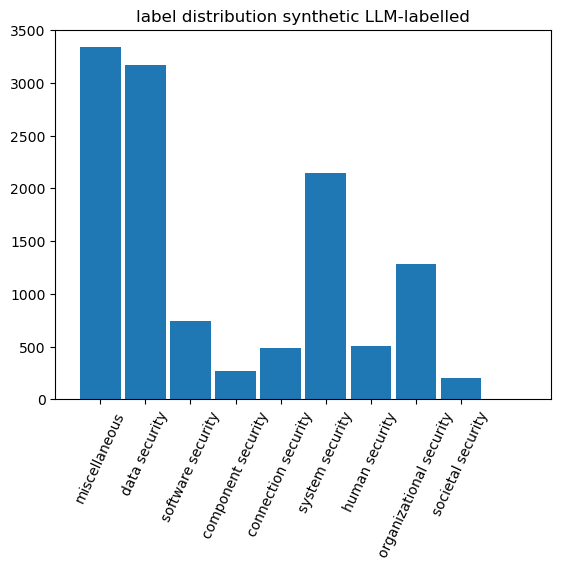

In [31]:
# check labels 
import matplotlib.pyplot as plt 
from collections import Counter 
dataset = copy.deepcopy(dataset2)
non_oh = np.concatenate([list(np.where(np.array(row)==1.)[0]) for row in dataset['labels']], axis=0)
counts, bins = np.histogram(non_oh, bins=[0,1,2,3,4,5,6,7,8,9])
counts = np.bincount(non_oh)
print(counts)

x_labels = ["miscellaneous", "data security", "software security", "component security", "connection security", 
            "system security", "human security",  "organizational security","societal security"]
# plot histogram of labels 
fig, ax = plt.subplots();
ax.bar(range(9), counts, width=0.9, align='center');
ax.set(xticks=range(9), xlim=[-1,10]);
ax.set_xticks(np.arange(len(x_labels)))
ax.set_xticklabels(x_labels, rotation=65)
ax.set_title('label distribution synthetic LLM-labelled')

In [95]:
print(non_oh[1000:2000])

[1 5 4 1 1 0 1 0 1 5 7 1 5 1 4 6 5 0 0 0 0 0 5 4 0 5 1 4 0 1 5 1 1 5 1 5 1
 1 1 1 5 1 1 1 1 0 1 5 1 0 1 1 1 5 7 1 5 5 0 1 1 7 4 4 1 1 1 5 5 1 5 0 5 0
 5 1 1 1 5 1 1 1 1 1 0 1 5 7 1 0 4 1 5 5 5 5 0 1 1 4 5 1 1 5 0 0 4 0 0 0 5
 1 4 1 5 1 5 1 5 1 0 1 5 7 0 1 0 4 5 0 5 1 5 0 1 5 7 5 0 5 0 1 5 1 1 1 1 0
 5 1 1 7 0 0 0 1 1 5 0 1 0 6 5 7 5 5 0 5 0 1 1 0 1 5 7 7 0 1 5 1 5 1 1 5 1
 2 0 1 5 1 1 5 0 1 5 7 1 5 6 0 5 0 5 0 7 1 0 4 0 0 4 1 1 0 1 5 1 5 5 0 2 1
 5 5 1 5 4 4 1 5 1 5 1 1 1 1 1 1 1 1 0 1 5 7 1 5 4 5 5 4 1 7 0 5 5 5 1 1 1
 5 1 7 1 0 1 0 1 5 7 4 0 0 0 1 5 5 0 0 5 1 5 7 4 5 0 6 0 5 1 1 1 5 6 1 1 0
 1 5 7 1 5 0 5 5 6 5 0 7 4 1 5 1 5 1 1 1 0 5 1 0 1 5 5 0 5 5 1 5 1 5 5 0 0
 1 0 4 1 1 5 0 1 0 1 6 1 0 7 7 1 5 0 0 1 1 1 1 4 4 4 4 1 1 5 0 1 5 7 1 6 5
 0 7 1 1 1 1 1 1 7 1 5 5 0 0 1 4 0 1 1 5 1 5 1 1 1 5 0 5 1 4 5 7 1 5 2 5 1
 5 5 0 4 0 0 5 6 0 5 5 0 1 4 1 4 1 7 0 0 4 0 7 0 0 0 0 1 5 7 1 0 1 5 4 1 4
 7 5 7 0 0 0 0 1 5 7 1 5 5 0 0 4 4 1 4 7 1 1 1 0 1 5 0 1 0 0 1 5 1 5 1 7 0
 5 5 0 0 1 0 0 1 5 7 1 1 

[1. 1. 1. ... 5. 7. 0.]
[ 922 1340   27    0  246  916   37  321]


Text(0.5, 1.0, 'label distribution synthetic pseudo-labelled')

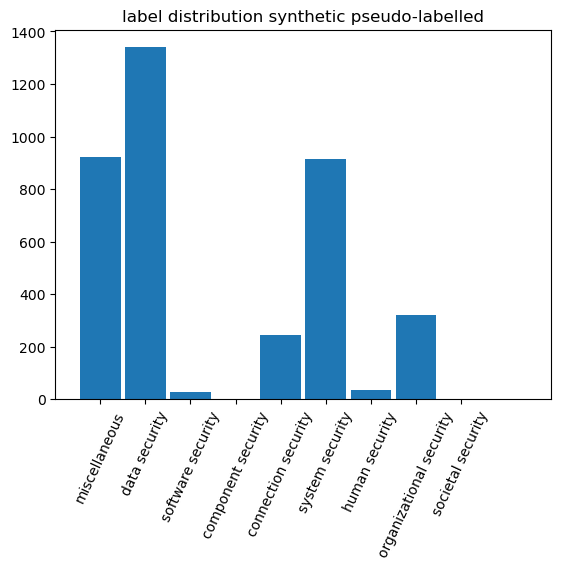

In [92]:
# check labels 
import matplotlib.pyplot as plt 
from collections import Counter 
dataset = copy.deepcopy(synthetic_ds)
non_oh = np.concatenate([list(np.where(np.array(row)==1.)[0]) for row in np.array(confident_indices, dtype='int32')], axis=0)
print(non_oh)
non_oh = np.array(non_oh, dtype='int64')
counts, bins = np.histogram(non_oh, bins=[0,1,2,3,4,5,6,7,8,9])
counts = np.bincount(non_oh)
print(counts)

x_labels = ["miscellaneous", "data security", "software security", "component security", "connection security", 
            "system security", "human security",  "organizational security","societal security"]
# plot histogram of labels 
fig, ax = plt.subplots();
ax.bar(range(8), counts, width=0.9, align='center');
ax.set(xticks=range(8), xlim=[-1,10]);
ax.set_xticks(np.arange(len(x_labels)))
ax.set_xticklabels(x_labels, rotation=65)
ax.set_title('label distribution synthetic pseudo-labelled')

### Evaluation

In [19]:
labels = np.concatenate([np.array(v) for v in trans.dict1.values()])
print(labels)
predictions = np.concatenate([np.array(v) for v in trans.dict2.values()])
#print(predictions)
pred0 = sigmoid(predictions)
pred0 = (pred0 > 0.5).astype(int).reshape(-1)
metrics1 = clf_metrics.compute(predictions=pred0, references=labels.astype(int).reshape(-1))
print(metrics1)
opt_thresholds = find_optimal_thresholds(labels,predictions)
print('opt_thresholds: ', opt_thresholds)
predictions = (sigmoid(predictions) >= 0.5) #np.array([opt_thresholds[i] for i in range(9)]))
predictions = np.array(predictions, dtype=np.int32)
metrics2 = clf_metrics.compute(predictions=predictions.reshape(-1), references=labels.astype(int).reshape(-1))
print(metrics2)
conf_matrix = multilabel_confusion_matrix(labels.astype(int), predictions)

[[0. 0. 0. ... 0. 1. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 1. 0. ... 0. 1. 0.]
 ...
 [0. 0. 0. ... 0. 1. 0.]
 [0. 0. 0. ... 0. 1. 0.]
 [0. 0. 0. ... 1. 0. 0.]]
{'accuracy': 0.8070987654320988, 'f1': 0.5140913508260447, 'precision': 0.37070777855641207, 'recall': 0.838351822503962}
opt_thresholds:  {0: 0.92583656, 1: 0.95438826, 2: 0.53133196, 3: 0.99437416, 4: 0.91823566, 5: 0.88097477, 6: 0.25828633, 7: 0.92637193, 8: 0.6716871}
{'accuracy': 0.8070987654320988, 'f1': 0.5140913508260447, 'precision': 0.37070777855641207, 'recall': 0.838351822503962}


[[[214 157]
  [ 21 184]]

 [[413 110]
  [ 14  39]]

 [[520  30]
  [  6  20]]

 [[533  27]
  [  8   8]]

 [[413  83]
  [ 16  64]]

 [[373 151]
  [ 15  37]]

 [[550  21]
  [  5   0]]

 [[102 298]
  [ 10 166]]

 [[537  21]
  [  7  11]]]
[184  39  20   8  64  37   0 166  11]
[157 110  30  27  83 151  21 298  21]
[21 14  6  8 16 15  5 10  7]


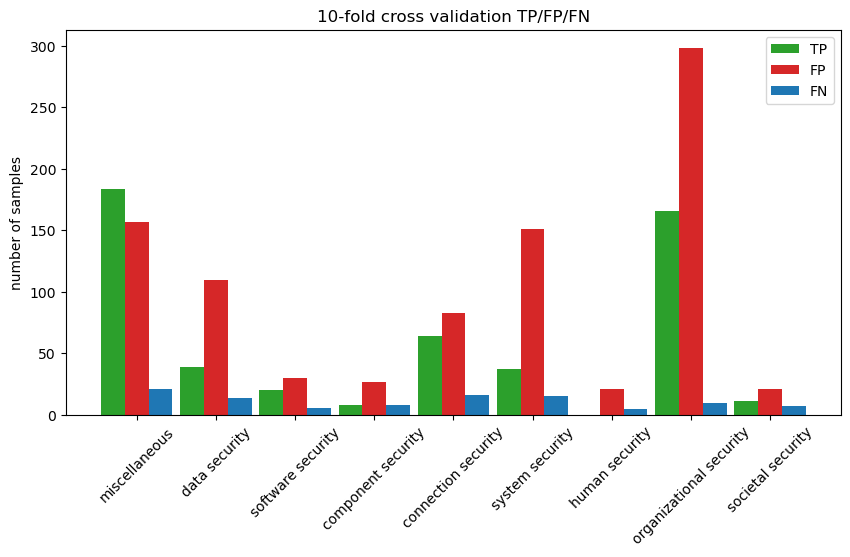

In [21]:
import matplotlib.pyplot as plt 
# turn this into a column plot. 
print(conf_matrix)
TP = conf_matrix[:,1,1]
print(TP)
FP = conf_matrix[:,0,1]
FN = conf_matrix[:,1,0]
print(FP)
print(FN)

# plot 
x_labels = ["miscellaneous", "data security", "software security", "component security", "connection security", 
            "system security", "human security",  "organizational security","societal security"]
x = np.arange(len(x_labels))

width = 0.3 
fig, ax = plt.subplots(figsize=(10,5))

ax.bar(x-width, TP, width,label='TP', color='tab:green')
ax.bar(x, FP, width, label= 'FP', color='tab:red')
ax.bar(x + width, FN, width, label='FN', color='tab:blue')
ax.set_xticks(x)
ax.set_xticklabels(x_labels, rotation=45)
ax.set_ylabel('number of samples')
ax.set_title('10-fold cross validation TP/FP/FN')
ax.legend()

[205  53  26  16  80  52   5 176  18]


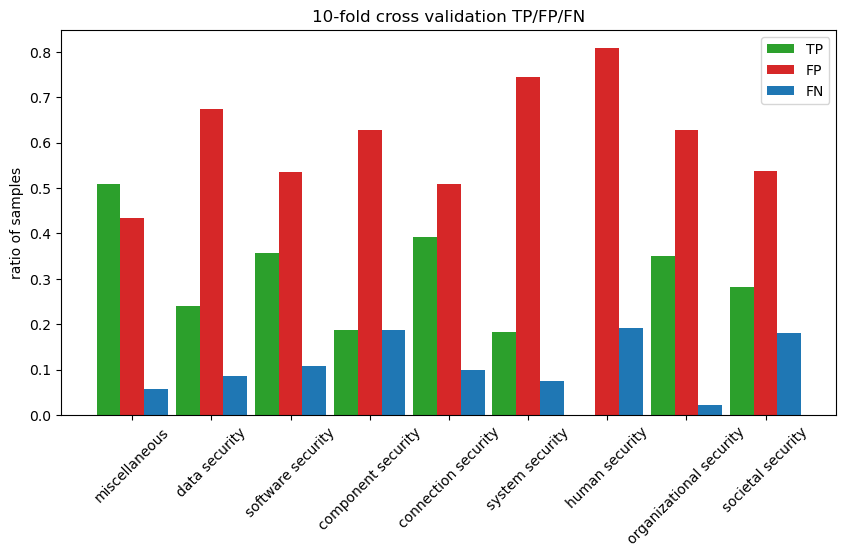

In [22]:
# same but normalized 
dataset = copy.deepcopy(trans.data)
non_oh = np.concatenate([list(np.where(np.array(row)==1.)[0]) for row in dataset['labels']], axis=0)
counts, bins = np.histogram(non_oh, bins=[0,1,2,3,4,5,6,7,8,9])
counts = np.bincount(non_oh)
print(counts)

x_labels = ["miscellaneous", "data security", "software security", "component security", "connection security", 
            "system security", "human security",  "organizational security","societal security"]
x = np.arange(len(x_labels))

width = 0.3 
fig, ax = plt.subplots(figsize=(10,5))

ax.bar(x-width, TP/(TP+FP+FN), width,label='TP', color='tab:green')
ax.bar(x, FP/(TP+FP+FN), width, label= 'FP', color='tab:red')
ax.bar(x + width, FN/(TP+FP+FN), width, label='FN', color='tab:blue')
ax.set_xticks(x)
ax.set_xticklabels(x_labels, rotation=45)
ax.set_ylabel('ratio of samples')
ax.set_title('10-fold cross validation TP/FP/FN')
ax.legend()

roc_auc:  [0.73719019 0.762762   0.85734266 0.72589286 0.81633065 0.71168526
 0.48161121 0.59909091 0.78673835]
f1:  0.5140913508260447
f1:  [0.673992673992674, 0.3861386138613861, 0.5263157894736842, 0.3137254901960784, 0.5638766519823789, 0.30833333333333335, 0.0, 0.51875, 0.44000000000000006, 0.5140913508260447]
[0.7371901913089212, 0.7627620044013131, 0.8573426573426572, 0.7258928571428571, 0.8163306451612903, 0.711685261303582, 0.4816112084063047, 0.5990909090909091, 0.7867383512544803, 0.8205596143049132]


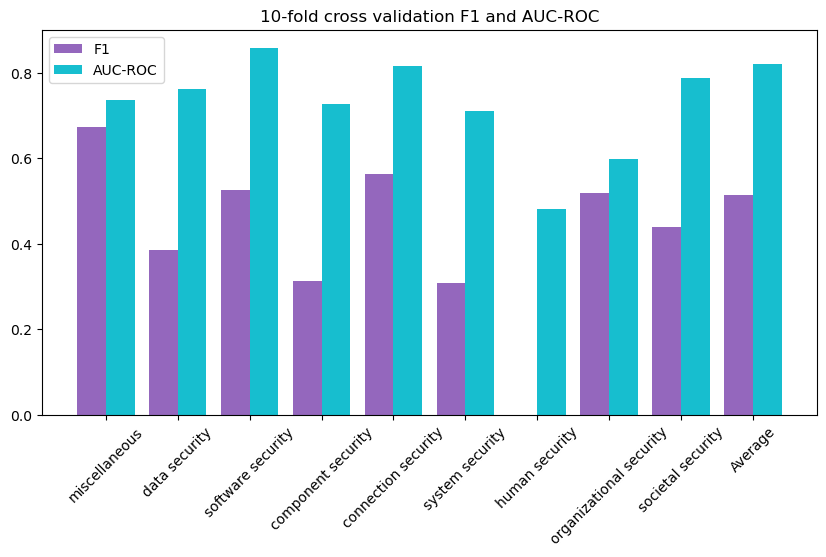

In [25]:
f1s = f1_score(y_pred=predictions, y_true=labels.astype(int),
                        average=None)

x_labels = ["miscellaneous", "data security", "software security", "component security", "connection security", 
            "system security", "human security",  "organizational security","societal security", "Average"]
x = np.arange(len(x_labels))

rocs = roc_auc_score(y_score=predictions, y_true=labels.astype(int),
                        average=None,multi_class='ovr')
print('roc_auc: ',rocs)
#print('f1: ',f1_score(y_pred=predictions, y_true=labels.astype(int),
 #                       average='macro')) # -> if all classes are equally important
print('f1: ',f1_score(y_pred=predictions, y_true=labels.astype(int),
                        average='micro')) # -> if all samples are equally important 
avg_f1 = f1_score(y_pred=predictions, y_true=labels.astype(int),
                        average='micro')
f1s = [x for x in f1s]
f1s.append(avg_f1)
print('f1: ',f1s)
avg_roc = roc_auc_score(y_score=predictions, y_true=labels.astype(int),
                        average='micro',multi_class='ovr')
rocs = [x for x in rocs]
rocs.append(avg_roc)
print(rocs)
width = 0.4
fig, ax = plt.subplots(figsize=(10,5))

ax.bar(x-width/2, f1s, width,label='F1', color='tab:purple')
#ax.bar(x, FP, width, label= 'FP', color='r')
ax.bar(x + width/2, rocs, width, label='AUC-ROC', color='tab:cyan')
ax.set_xticks(x)
ax.set_xticklabels(x_labels, rotation=45)
ax.set_title('10-fold cross validation F1 and AUC-ROC')
ax.legend()

In [19]:
clf_metrics = evaluate.combine(["accuracy", "f1", "precision", "recall"])
pr = evaluate.load('precision')
re = evaluate.load('recall')
f1 = evaluate.load('f1') 
acc = evaluate.load('accuracy')

print('precision: ',pr.compute(predictions=predictions.reshape(-1), references=labels.astype(int).reshape(-1)))
print('recall: ',re.compute(predictions=predictions.reshape(-1), references=labels.astype(int).reshape(-1)))
print('f1: ',f1.compute(predictions=predictions.reshape(-1), references=labels.astype(int).reshape(-1)))
print('acc: ',acc.compute(predictions=predictions.reshape(-1), references=labels.astype(int).reshape(-1)))

metrics2 = clf_metrics.compute(predictions=predictions.reshape(-1), references=labels.astype(int).reshape(-1))
print(metrics2)

precision:  {'precision': 0.628140703517588}
recall:  {'recall': 0.5942947702060222}
f1:  {'f1': 0.6107491856677525}
acc:  {'accuracy': 0.9077932098765432}
{'accuracy': 0.9077932098765432, 'f1': 0.6107491856677525, 'precision': 0.628140703517588, 'recall': 0.5942947702060222}


In [24]:
from sklearn.metrics import f1_score, roc_auc_score, accuracy_score 
from transformers import EvalPrediction
import torch 
print('accuracy: ',accuracy_score(y_pred=predictions, y_true=labels.astype(int)))
print('f1: ',f1_score(y_pred=predictions, y_true=labels.astype(int),
                        average='micro'))
print('f1: ',f1_score(y_pred=predictions, y_true=labels.astype(int),
                        average='macro'))
print('f1: ',f1_score(y_pred=predictions, y_true=labels.astype(int),
                        average=None))
print('f1: ',f1_score(y_pred=predictions, y_true=labels.astype(int),
                        average='samples'))
print('roc_auc: ',roc_auc_score(y_score=predictions, y_true=labels.astype(int),
                        average=None,multi_class='ovr'))
print('roc_auc: ',roc_auc_score(y_score=predictions, y_true=labels.astype(int),
                        average='micro',multi_class='ovr')) # only implemented for ovr
print('roc_auc: ',roc_auc_score(y_score=predictions, y_true=labels.astype(int),
                        average='macro',multi_class='ovo'))
print('roc_auc: ',roc_auc_score(y_score=predictions, y_true=labels.astype(int),
                        average='macro',multi_class='ovr'))

accuracy:  0.08680555555555555
f1:  0.5140913508260447
f1:  0.4145702836488372
f1:  [0.67399267 0.38613861 0.52631579 0.31372549 0.56387665 0.30833333
 0.         0.51875    0.44      ]
f1:  0.5373759920634922
roc_auc:  [0.73719019 0.762762   0.85734266 0.72589286 0.81633065 0.71168526
 0.48161121 0.59909091 0.78673835]
roc_auc:  0.8205596143049132
roc_auc:  0.7198493428235906
roc_auc:  0.7198493428235906


In [49]:
print('f1: ',f1.compute(predictions=predictions.reshape(-1), references=labels.astype(int).reshape(-1),
                        average='micro'))
print('f1: ',f1.compute(predictions=predictions.reshape(-1), references=labels.astype(int).reshape(-1),
                        average='macro'))
print('f1: ',f1.compute(predictions=predictions.reshape(-1), references=labels.astype(int).reshape(-1),
                        average='weighted'))
#print('f1: ',f1.compute(predictions=predictions, references=labels.astype(int),
   #                     average='samples'))
print('f1: ',f1.compute(predictions=predictions.reshape(-1), references=labels.astype(int).reshape(-1),
                        average=None))

f1:  {'f1': 0.9068287037037037}
f1:  {'f1': 0.7792462337032589}
f1:  {'f1': 0.9062136144040314}
f1:  {'f1': array([0.94706849, 0.61142397])}


In [40]:
print(labels)
labels_flatten = labels.astype(int).reshape(-1)
print(labels_flatten)
num_classes = labels.shape[1]
print(num_classes)
classes = np.arange(num_classes)
y_true_labels = np.argmax(labels, axis=1)
print(y_true_labels)

[[0. 0. 0. ... 0. 1. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 1. 0. ... 0. 1. 0.]
 ...
 [0. 0. 0. ... 0. 1. 0.]
 [0. 0. 0. ... 0. 1. 0.]
 [0. 0. 0. ... 1. 0. 0.]]
[0 0 0 ... 1 0 0]
9
[7 4 1 4 0 4 0 0 6 4 1 0 0 8 3 4 0 4 1 8 0 7 5 2 2 3 5 7 1 1 0 0 0 2 0 0 0
 7 0 5 0 7 7 7 4 0 4 7 7 7 7 0 0 0 0 7 7 7 7 4 5 0 1 7 4 7 4 4 1 2 5 7 2 2
 0 7 4 4 0 1 7 7 8 3 7 8 4 5 0 0 7 0 0 0 7 0 7 0 0 5 4 0 0 7 7 1 0 0 0 0 0
 0 4 0 0 7 7 4 5 3 2 2 7 5 4 0 1 1 8 0 2 0 0 7 4 7 0 0 5 7 7 5 7 5 4 1 7 0
 0 0 0 0 0 0 0 7 7 0 4 7 8 1 0 7 7 4 0 0 0 7 0 0 4 7 5 2 1 0 7 4 1 7 5 7 7
 0 7 1 0 2 3 4 1 0 5 5 0 8 0 5 7 0 0 0 0 8 4 7 7 0 0 0 7 0 4 0 0 0 0 1 4 4
 7 7 0 4 0 7 7 7 0 7 2 0 7 5 7 4 0 7 4 8 2 0 0 5 0 1 1 3 5 1 2 0 7 7 7 0 4
 0 0 7 0 5 1 0 7 1 4 4 0 0 7 0 7 7 4 0 0 5 7 0 7 7 7 0 0 0 4 0 0 0 7 5 4 7
 7 1 4 4 0 7 0 0 2 7 3 0 1 2 7 7 5 0 4 7 5 7 7 0 0 1 5 4 0 0 5 7 7 1 4 1 0
 4 8 1 7 0 0 0 7 0 0 0 0 0 7 0 0 3 7 0 2 5 7 7 3 2 0 7 1 1 1 7 1 7 5 7 0 0
 4 7 0 2 8 7 7 5 4 0 7 0 7 0 0 4 7 4 0 0 0 1 0 4 7 0 0 0 0 1 0 7 4 0 4 4 6

In [ ]:
# 1: {0: 0.6209465, 1: 0.68818504, 2: 0.304136, 3: 0.19678949, 4: 0.5968294, 5: 0.617112, 6: 0.1, 7: 0.1, 8: 0.64489603}
# 2:  {0: 0.24061964, 1: 0.78145397, 2: 0.695997, 3: 0.1, 4: 0.13399822, 5: 0.1, 6: 0.1, 7: 0.1, 8: 0.61317796}
# 3:  {0: 0.47256878, 1: 0.62380856, 2: 0.84090495, 3: 0.1, 4: 0.38239574, 5: 0.32536218, 6: 0.1, 7: 0.1, 8: 0.22386967}
# 4: {0: 0.2033262, 1: 0.92462945, 2: 0.109336086, 3: 0.66224056, 4: 0.95036566, 5: 0.81877095, 6: 0.1, 7: 0.48430315, 8: 0.1}
# 5:  {0: 0.1, 1: 0.40172708, 2: 0.88310397, 3: 0.6525466, 4: 0.94306505, 5: 0.5191577, 6: 0.1, 7: 0.25154173, 8: 0.1}
# 6: {0: 0.40362564, 1: 0.52831316, 2: 0.3910481, 3: 0.3065164, 4: 0.1, 5: 0.6973592, 6: 0.1, 7: 0.20413958, 8: 0.1}
# 7:  {0: 0.1, 1: 0.11727965, 2: 0.1, 3: 0.1, 4: 0.1, 5: 0.5658802, 6: 0.1, 7: 0.5891888, 8: 0.18163867}
# 8:  {0: 0.4569763, 1: 0.44103664, 2: 0.54543567, 3: 0.1, 4: 0.1, 5: 0.19169478, 6: 0.1, 7: 0.35678333, 8: 0.1}
# 9:  {0: 0.1, 1: 0.53977114, 2: 0.1, 3: 0.1, 4: 0.1, 5: 0.10363863, 6: 0.1, 7: 0.969054, 8: 0.747978}
# 10: {0: 0.24453712, 1: 0.19374, 2: 0.5176003, 3: 0.62935174, 4: 0.8346007, 5: 0.14620653, 6: 0.1, 7: 0.1191715, 8: 0.85948366}

# average: 
avg_thresholds = 

# {0: 0.09010855, 1: 0.8070916, 2: 0.16622421, 3: 0.17744192, 4: 0.69113195, 5: 0.082478225, 6: 0.005615593, 7: 0.16459411, 8: 0.14234924}
# {0: 0.15494835, 1: 0.08767713, 2: 0.5830012, 3: 0.072481155, 4: 0.5985058, 5: 0.22885211, 6: 0.0013765882, 7: 0.14917901, 8: 0.2064089}
# {0: 0.298874, 1: 0.27406466, 2: 0.26362708, 3: 0.23404479, 4: 0.08124954, 5: 0.20858617, 6: 0.0053683277, 7: 0.104936354, 8: 0.34774435}
# {0: 0.7309446, 1: 0.19085313, 2: 0.63693374, 3: 0.035732005, 4: 0.8454907, 5: 0.5142516, 6: 0.006813353, 7: 0.6126626, 8: 0.12834346}
# {0: 0.6434473, 1: 0.59113926, 2: 0.2502423, 3: 0.41778016, 4: 0.907993, 5: 0.11438393, 6: 0.039156552, 7: 0.053031176, 8: 0.11982923}

# average: 
# {0: 0.09010855, 1: 0.8070916, 2: 0.16622421, 3: 0.17744192, 4: 0.69113195, 5: 0.082478225, 6: 0.005615593, 7: 0.16459411, 8: 0.14234924}

In [27]:
# 
from sklearn.metrics import precision_recall_curve, f1_score

def find_optimal_thresholds(y_true, y_probs): 
    y_probs = sigmoid(y_probs)
    num_classes = y_true.shape[1]
    thresholds = {} 
    for i in range(num_classes): 
        precision, recall, threshold_vals = precision_recall_curve(y_true[:,i], y_probs[:,i])
        f1_scores = 2*(precision*recall) / (precision + recall + 1e-9)
        best_threshold = threshold_vals[np.argmax(f1_scores)]
        if best_threshold < 0.1: 
            best_threshold = 0.1 
        thresholds[i] = best_threshold
    return thresholds

outputs = trans.trainer.predict(trans.val_dataset)
opt_thresholds = find_optimal_thresholds(outputs[1],outputs[0])
y_pred = (sigmoid(outputs[0]) >= np.array([opt_thresholds[i] for i in range(9)]))
y_pred = np.array(y_pred, dtype=np.int32)
labels = outputs[1]
print(opt_thresholds)
print(clf_metrics.compute(predictions=y_pred.reshape(-1), references=labels.astype(int).reshape(-1)))

{0: 0.24453712, 1: 0.19374, 2: 0.5176003, 3: 0.62935174, 4: 0.8346007, 5: 0.14620653, 6: 0.1, 7: 0.1191715, 8: 0.85948366}
{'accuracy': 0.9122807017543859, 'f1': 0.6666666666666667, 'precision': 0.6081081081081081, 'recall': 0.7377049180327869}


In [24]:
from sklearn.metrics import precision_recall_curve, f1_score

def find_optimal_thresholds(y_true, y_probs): 
    y_probs = sigmoid(y_probs)
    num_classes = y_true.shape[1]
    thresholds = {} 
    for i in range(num_classes): 
        precision, recall, threshold_vals = precision_recall_curve(y_true, y_probs)
        f1_scores = 2*(precision*recall) / (precision + recall + 1e-9)
        best_threshold = threshold_vals[np.argmax(f1_scores)]
        thresholds[i] = best_threshold
    return thresholds

outputs = trans.trainer.predict(trans.val_dataset)
opt_thresholds = find_optimal_thresholds(outputs[1],outputs[0])
y_pred = (sigmoid(outputs[0]) >= np.array([opt_thresholds[i] for i in range(9)]))
y_pred = np.array(y_pred, dtype=np.int32)
labels = outputs[1]
print(opt_thresholds)
print(clf_metrics.compute(predictions=y_pred.reshape(-1), references=labels.astype(int).reshape(-1)))

ValueError: multilabel-indicator format is not supported

In [16]:
# switch around thresholds: 
def compute_metrics(eval_pred, th):
   predictions = eval_pred[0]
   labels = eval_pred[1]
   predictions = sigmoid(predictions)
   predictions = (predictions > th).astype(int).reshape(-1)
   return clf_metrics.compute(predictions=predictions, references=labels.astype(int).reshape(-1))

outputs = trans.trainer.predict(trans.val_dataset)


{'accuracy': 0.9042145593869731, 'f1': 0.5689655172413793, 'precision': 0.6226415094339622, 'recall': 0.5238095238095238}


In [7]:
# load 2017 KDs
dataset = datasets.load_dataset("csv",data_files={"train": "data/train_data.csv"}, split='train')
dataset = dataset.remove_columns('KSAT ID')
print(dataset)
train_val_split = dataset.train_test_split(test_size=0.1, seed=42) 
train_dataset = train_val_split['train']
val_dataset = train_val_split['test']

Dataset({
    features: ['0', '1', '2', '3', '4', '5', '6', '7', '8', 'Statement Description'],
    num_rows: 576
})


In [52]:
# load synthetic dataset 
import pandas as pd
from datasets import Dataset 
input1 = pd.read_csv("data/train_synthetic_v1.csv")
input2 = pd.read_csv("data/train_synthetic_v1_labels.csv")
input1 = input2.merge(input1, on="Unnamed: 0", how='right')
dataset2 = Dataset.from_pandas(input1)
dataset2 = dataset2.remove_columns(['Unnamed: 0','label'])
print(dataset2)
# merge train_dataset with synthetic dataset. 
from datasets import concatenate_datasets 
train_dataset = concatenate_datasets([train_dataset, dataset2])
print(train_dataset)

Dataset({
    features: ['0', '1', '2', '3', '4', '5', '6', '7', '8', 'Statement Description'],
    num_rows: 1548
})


Dataset({
    features: ['0', '1', '2', '3', '4', '5', '6', '7', '8', 'Statement Description'],
    num_rows: 2066
})


### Define functions (import these in a later stage). 

### Tokenize dataset 

In [55]:
from transformers import AutoTokenizer
tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")

In [56]:
tokenized_train = train_dataset.map(preprocess_function) 
tokenized_val = val_dataset.map(preprocess_function)
print(tokenized_train)

Map:   0%|          | 0/2066 [00:00<?, ? examples/s]

Map:   0%|          | 0/58 [00:00<?, ? examples/s]

Dataset({
    features: ['0', '1', '2', '3', '4', '5', '6', '7', '8', 'Statement Description', 'input_ids', 'attention_mask', 'labels'],
    num_rows: 2066
})


### Fine-tune with Trainer 

In [75]:
from transformers import AutoModelForSequenceClassification, TrainingArguments, Trainer
from transformers import DataCollatorWithPadding
# to create a batch of examples. This dynamically pads the text to the lenght of the longest element in the batch. 
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)
model = AutoModelForSequenceClassification.from_pretrained("distilbert-base-uncased", num_labels=num_classes)
#from torchinfo import summary 
#summary(model)

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [80]:
training_args = TrainingArguments(
    output_dir="DistilBERTv2",
    learning_rate=2e-5,
    per_device_train_batch_size=4,
    per_device_eval_batch_size=16,
    num_train_epochs=25,
    weight_decay=0.01,
    logging_steps=100,
    # I added these three 
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    save_total_limit=1,
)

trainer = CustomTrainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_val,
    tokenizer=tokenizer,
    data_collator=data_collator,
    # I added this to compute metrics. 
    compute_metrics=compute_metrics,
)

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
/local/tmp.3422166/ipykernel_2239932/910210077.py:16: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `CustomTrainer.__init__`. Use `processing_class` instead.
  trainer = CustomTrainer(
Detected kernel version 4.18.0, which is below the recommended minimum of 5.5.0; this can cause the process to hang. It is recommended to upgrade the kernel to the minimum version or higher.


In [81]:
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,1.062800,2.398516,0.829502,0.485549,0.371681,0.700000
2,0.874200,2.134770,0.837165,0.519774,0.393162,0.766667
3,0.884000,3.092497,0.850575,0.486842,0.402174,0.616667
4,0.884300,2.712057,0.862069,0.538462,0.437500,0.700000
5,0.751100,2.608346,0.879310,0.553191,0.481481,0.650000
6,0.777100,3.074444,0.844828,0.477419,0.389474,0.616667
7,0.967900,2.444560,0.871648,0.524823,0.456790,0.616667
8,0.803800,2.747569,0.865900,0.507042,0.439024,0.600000
9,0.844900,2.636265,0.862069,0.506849,0.430233,0.616667
10,1.007100,2.685127,0.871648,0.503704,0.453333,0.566667


TrainOutput(global_step=12925, training_loss=0.762486086389774, metrics={'train_runtime': 549.3388, 'train_samples_per_second': 94.022, 'train_steps_per_second': 23.528, 'total_flos': 171599299593876.0, 'train_loss': 0.762486086389774, 'epoch': 25.0})

In [ ]:
# 

### Evaluation

In [84]:
import os
from transformers import AutoModelForSequenceClassification, TrainingArguments, Trainer
from transformers import AutoConfig
import sys
sys.path.append("/mimer/NOBACKUP/groups/naiss2024-22-903/LLMedu")
print(os.path.exists("/mimer/NOBACKUP/groups/naiss2024-22-903/LLMedu/DistilBERTv1/checkpoint-130/config.json"))
path = "/mimer/NOBACKUP/groups/naiss2024-22-903/LLMedu/DistilBERTv2/checkpoint-1034/"
print(os.path.isfile("/mimer/NOBACKUP/groups/naiss2024-22-903/LLMedu/DistilBERTv1/checkpoint-130/config.json"))
#config = AutoConfig.from_pretrained("local:/mimer/NOBACKUP/groups/naiss2024-22-903/LLMedu/DistilBERTv1/checkpoint-130")
#"./DistilBERTv1/checkpoint-130/config.json"
model = AutoModelForSequenceClassification.from_pretrained(path
                                                           , num_labels=num_classes)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_val,
    tokenizer=tokenizer,
    data_collator=data_collator,
    # I added this to compute metrics. 
    compute_metrics=compute_metrics,
)

# load the best weights and inspect. 
# plot confusion matrices! 
from sklearn.metrics import multilabel_confusion_matrix
import os 
from transformers.trainer_callback import TrainerState 

labels = np.zeros((len(dataset),num_classes))
preds = np.zeros((len(dataset),num_classes))
output = trainer.predict(tokenized_val)
#print(output)
predictions = sigmoid(output[0])
predictions = (predictions > 0.5).astype(int) #.reshape(-1)

print(multilabel_confusion_matrix(output[1].astype(int), predictions))
# [ TN FP ]
# [ FN TP ] 
# maybe plot this as column plots? 

/local/tmp.3422166/ipykernel_2239932/1519345436.py:14: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(
Detected kernel version 4.18.0, which is below the recommended minimum of 5.5.0; this can cause the process to hang. It is recommended to upgrade the kernel to the minimum version or higher.


False
False


[[[30 13]
  [ 2 13]]

 [[41 15]
  [ 1  1]]

 [[52  3]
  [ 1  2]]

 [[55  0]
  [ 1  2]]

 [[40  7]
  [ 2  9]]

 [[43 11]
  [ 2  2]]

 [[56  2]
  [ 0  0]]

 [[24 15]
  [ 2 17]]

 [[50  5]
  [ 3  0]]]


In [55]:
from transformers import AutoModelForSequenceClassification, TrainingArguments, Trainer
from transformers import AutoConfig
import sys
sys.path.append("/mimer/NOBACKUP/groups/naiss2024-22-903/LLMedu")
print(os.path.exists("/mimer/NOBACKUP/groups/naiss2024-22-903/LLMedu/DistilBERTv1/checkpoint-130/config.json"))
path = "/mimer/NOBACKUP/groups/naiss2024-22-903/LLMedu/DistilBERTv1/checkpoint-130/"
print(os.path.isfile("/mimer/NOBACKUP/groups/naiss2024-22-903/LLMedu/DistilBERTv1/checkpoint-130/config.json"))
#config = AutoConfig.from_pretrained("local:/mimer/NOBACKUP/groups/naiss2024-22-903/LLMedu/DistilBERTv1/checkpoint-130")
#"./DistilBERTv1/checkpoint-130/config.json"
model = AutoModelForSequenceClassification.from_pretrained(path
                                                           , num_labels=num_classes)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_val,
    tokenizer=tokenizer,
    data_collator=data_collator,
    # I added this to compute metrics. 
    compute_metrics=compute_metrics,
)

# load the best weights and inspect. 
# plot confusion matrices! 
from sklearn.metrics import multilabel_confusion_matrix
import os 
from transformers.trainer_callback import TrainerState 

labels = np.zeros((len(dataset),num_classes))
preds = np.zeros((len(dataset),num_classes))
output = trainer.predict(tokenized_val)
#print(output)
predictions = sigmoid(output[0])
predictions = (predictions > 0.5).astype(int) #.reshape(-1)

print(multilabel_confusion_matrix(output[1].astype(int), predictions))
# [ TN FP ]
# [ FN TP ] 
# maybe plot this as column plots? 

/local/tmp.3405036/ipykernel_1667434/1019722757.py:13: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(
Detected kernel version 4.18.0, which is below the recommended minimum of 5.5.0; this can cause the process to hang. It is recommended to upgrade the kernel to the minimum version or higher.


True
True


[[[43  0]
  [ 2 13]]

 [[56  0]
  [ 0  2]]

 [[57  0]
  [ 1  0]]

 [[57  0]
  [ 1  0]]

 [[49  0]
  [ 2  7]]

 [[51  0]
  [ 7  0]]

 [[58  0]
  [ 0  0]]

 [[32  2]
  [ 1 23]]

 [[57  0]
  [ 1  0]]]


In [54]:
# load the best weights and inspect. 
# plot confusion matrices! 
from sklearn.metrics import multilabel_confusion_matrix
import os 
from transformers.trainer_callback import TrainerState 

labels = np.zeros((len(dataset),num_classes))
preds = np.zeros((len(dataset),num_classes))
output = trainer.predict(tokenized_val)
#print(output)
predictions = sigmoid(output[0])
predictions = (predictions > 0.5).astype(int) #.reshape(-1)

print(multilabel_confusion_matrix(output[1].astype(int), predictions))
# [ TN FP ]
# [ FN TP ] 
# maybe plot this as column plots? 

[[[43  0]
  [ 2 13]]

 [[56  0]
  [ 0  2]]

 [[57  0]
  [ 1  0]]

 [[57  0]
  [ 1  0]]

 [[49  0]
  [ 2  7]]

 [[51  0]
  [ 7  0]]

 [[58  0]
  [ 0  0]]

 [[32  2]
  [ 1 23]]

 [[57  0]
  [ 1  0]]]


In [28]:
# load the best weights and inspect. 
# plot confusion matrices! 
from sklearn.metrics import multilabel_confusion_matrix
import os 
from transformers.trainer_callback import TrainerState 
save_dir = "DistilBERTv2"
ckpt_dirs = os.listdir(save_dir)
print(ckpt_dirs)
#ckpt_dirs = sorted(ckpt_dirs, key=lambda x: int(x.split('-')[1]))
last_ckpt = ckpt_dirs[0]
print(last_ckpt)
state = TrainerState.load_from_json(f"{save_dir}/{last_ckpt}/trainer_state.json")
print(state.best_model_checkpoint)

#non_oh = [list(np.where(row==1)[0]) for row in labels]
#non_oh2 = [list(np.where(row==1)[0]) for row in preds]
labels = np.zeros((len(dataset),num_classes))
preds = np.zeros((len(dataset),num_classes))
output = trainer.predict(tokenized_val)
#print(output)
predictions = sigmoid(output[0])
predictions = (predictions > 0.5).astype(int) #.reshape(-1)

print(multilabel_confusion_matrix(output[1].astype(int), predictions))
# [ TN FP ]
# [ FN TP ] 
# maybe plot this as column plots? 

['checkpoint-4136', 'runs']
checkpoint-4136
DistilBERTv2/checkpoint-4136


[[[40  3]
  [ 3 12]]

 [[55  1]
  [ 0  2]]

 [[57  0]
  [ 1  0]]

 [[57  0]
  [ 1  0]]

 [[48  1]
  [ 7  2]]

 [[51  0]
  [ 4  3]]

 [[58  0]
  [ 0  0]]

 [[30  4]
  [ 7 17]]

 [[57  0]
  [ 1  0]]]


In [25]:
# load the best weights and inspect. 
import os 
from transformers.trainer_callback import TrainerState 
save_dir = "DistilBERTv1"
ckpt_dirs = os.listdir(save_dir)
print(ckpt_dirs)
#ckpt_dirs = sorted(ckpt_dirs, key=lambda x: int(x.split('-')[1]))
last_ckpt = ckpt_dirs[-1]
print(last_ckpt)
state = TrainerState.load_from_json(f"{save_dir}/{last_ckpt}/trainer_state.json")
print(state.best_model_checkpoint)

['runs', 'checkpoint-130']
checkpoint-130
DistilBERTv1/checkpoint-130


In [29]:
# plot confusion matrices! 
from sklearn.metrics import multilabel_confusion_matrix
#non_oh = [list(np.where(row==1)[0]) for row in labels]
#non_oh2 = [list(np.where(row==1)[0]) for row in preds]
labels = np.zeros((len(dataset),num_classes))
preds = np.zeros((len(dataset),num_classes))
output = trainer.predict(tokenized_val,load_from_checkpoint=True,save_dir = "DistilBERTv1")
#print(output)
predictions = sigmoid(output[0])
predictions = (predictions > 0.5).astype(int) #.reshape(-1)

print(multilabel_confusion_matrix(output[1].astype(int), predictions))
# [ TN FP ]
# [ FN TP ] 
# maybe plot this as column plots? 

TypeError: predict() got an unexpected keyword argument 'load_from_checkpoint'

In [56]:
print(tokenized_train['labels'][0])
c = tokenized_train['labels'][0]
print(c[0])
print(np.where(np.array(c)==1.))

[1.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
1.0
(array([0, 2]),)


(array([185.,  47.,  22.,  14.,   0.,  71.,  47.,   5., 162.,  16.]),
 array([0. , 0.8, 1.6, 2.4, 3.2, 4. , 4.8, 5.6, 6.4, 7.2, 8. ]),
 <BarContainer object of 10 artists>)

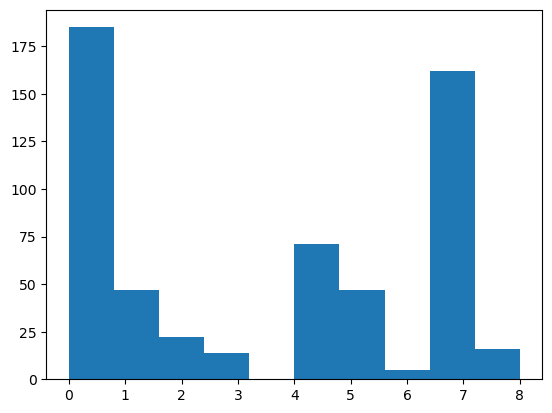

In [58]:
import matplotlib.pyplot as plt 
from collections import Counter 
non_oh = np.concatenate([list(np.where(np.array(row)==1.)[0]) for row in tokenized_train['labels']], axis=0)
counts, bins = np.histogram(non_oh)
plt.hist(bins[:-1], bins, weights=counts)

(array([20.,  6.,  4.,  2.,  0.,  9.,  5.,  0., 14.,  2.]),
 array([0. , 0.8, 1.6, 2.4, 3.2, 4. , 4.8, 5.6, 6.4, 7.2, 8. ]),
 <BarContainer object of 10 artists>)

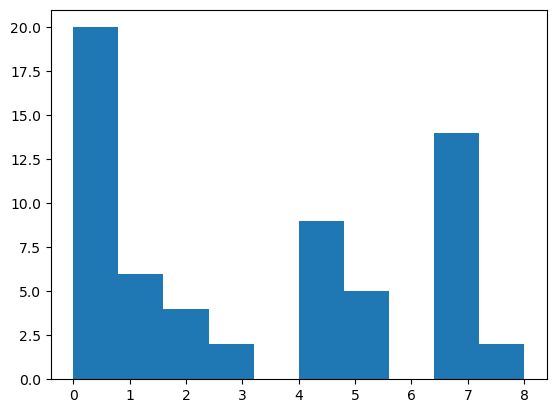

In [59]:
non_oh = np.concatenate([list(np.where(np.array(row)==1.)[0]) for row in tokenized_val['labels']], axis=0)
counts, bins = np.histogram(non_oh)
plt.hist(bins[:-1], bins, weights=counts)